In [112]:
%matplotlib inline
import math
import time
import numpy as np
import torch
import random
import matplotlib.pyplot as plt
from matplotlib_inline import backend_inline

def use_svg_display():  #@save
    #注释#@save是一个特殊的标记，会将对应的函数、类或语句保存在d2l包中。
    #因此，以后无须重新定义就可以直接调用它们（例如，d2l.use_svg_display()）
    """使用svg格式在Jupyter中显示绘图"""
    # 设置matplotlib的后端为svg格式
    backend_inline.set_matplotlib_formats('svg')

def set_figsize(figsize=(3.5, 2.5)):  #@save
    """设置matplotlib的图表大小"""
    use_svg_display()
    # 设置图表的尺寸
    plt.rcParams['figure.figsize'] = figsize

def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """设置matplotlib的轴"""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

def plot(X, Y=None, xlabel=None, ylabel=None, legend=None, xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None):
    """绘制数据点"""
    if legend is None:
        legend = []

    set_figsize(figsize)
    axes = axes if axes else plt.gca()

    # 如果X有一个轴，输出True
    def has_one_axis(X):
        return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list)
                and not hasattr(X[0], "__len__"))

    if has_one_axis(X):
        X = [X]
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y)
    axes.cla()
    for x, y, fmt in zip(X, Y, fmts):
        if len(x):
            axes.plot(x, y, fmt)
        else:
            axes.plot(y, fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

In [113]:
class Timer:  #@save
    """记录多次运行时间"""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """启动计时器"""
        self.tik = time.time()

    def stop(self):
        """停止计时器并将时间记录在列表中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def avg(self):
        """返回平均时间"""
        return sum(self.times) / len(self.times)

    def sum(self):
        """返回时间总和"""
        return sum(self.times)

    def cumsum(self):
        """返回累计时间"""
        return np.array(self.times).cumsum().tolist()

In [114]:
n = 10000
a = torch.ones([n])
b = torch.ones([n])

In [115]:
c = torch.zeros(n)
timer = Timer()
for i in range(n):
    c[i] = a[i] + b[i]
f'{timer.stop():.5f} sec'

'0.16206 sec'

In [116]:
timer.start()
d = a + b
f'{timer.stop():.5f} sec'

'0.00056 sec'

In [117]:
def normal(x, mu, sigma):
    p = 1 / math.sqrt(2 * math.pi * sigma**2)
    return p * np.exp(-0.5 / sigma**2 * (x - mu)**2)

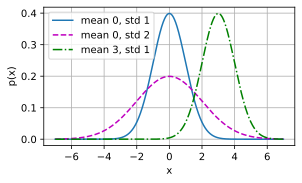

In [118]:
# 再次使用numpy进行可视化
x = np.arange(-7, 7, 0.01)

# 均值和标准差对
params = [(0, 1), (0, 2), (3, 1)]
plot(x, [normal(x, mu, sigma) for mu, sigma in params], xlabel='x',
         ylabel='p(x)', figsize=(4.5, 2.5),
         legend=[f'mean {mu}, std {sigma}' for mu, sigma in params])

这段是在画：**随着掷骰次数越来越多，每个点数的经验概率如何逐渐接近 `1/6`。**

先看这句：

```python
counts = multinomial.Multinomial(10, fair_probs).sample((500,))
```

意思是：

```text
做 500 组实验；
每组实验掷 10 次骰子；
每组统计 6 个面分别出现了几次。
```

所以 `counts` 的形状是：

```python
counts.shape
# torch.Size([500, 6])
```

可以想象成这样：

```text
第1组10次: [2, 1, 2, 3, 1, 1]
第2组10次: [0, 2, 1, 3, 3, 1]
第3组10次: [1, 1, 2, 2, 2, 2]
...
共500行
```

每一行加起来都是 `10`。

---

然后：

```python
cum_counts = counts.cumsum(dim=0)
```

`dim=0` 是沿着“行”累加。

假设前两行是：

```text
counts[0] = [2, 1, 2, 3, 1, 1]
counts[1] = [0, 2, 1, 3, 3, 1]
```

那么：

```text
cum_counts[0] = [2, 1, 2, 3, 1, 1]
cum_counts[1] = [2, 3, 3, 6, 4, 2]
```

也就是：

```text
前10次的累计结果
前20次的累计结果
前30次的累计结果
...
前5000次的累计结果
```

所以 `cum_counts` 的形状仍然是：

```python
torch.Size([500, 6])
```

第 `i` 行表示：到目前为止，每个骰子面累计出现了多少次。

---

然后：

```python
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)
```

这一步是在把“次数”变成“概率估计”。

```python
cum_counts.sum(dim=1, keepdims=True)
```

表示每一行求和。

因为每一组是 10 次，所以它大概是：

```text
[[10],
 [20],
 [30],
 ...
 [5000]]
```

注意 `keepdims=True` 让它保持二维形状：

```python
torch.Size([500, 1])
```

这样才能和：

```python
cum_counts.shape
# torch.Size([500, 6])
```

自动广播相除。

所以：

```python
estimates
```

也是：

```python
torch.Size([500, 6])
```

每一行表示：截至当前总投掷次数，6 个面的相对频率。

例如：

```text
cum_counts[1] = [2, 3, 3, 6, 4, 2]
总次数 = 20
estimates[1] = [0.10, 0.15, 0.15, 0.30, 0.20, 0.10]
```

---

最后画图：

```python
for i in range(6):
    plt.plot(estimates[:, i].numpy(),
             label=("P(die=" + str(i + 1) + ")"))
```

这里循环 `i = 0, 1, 2, 3, 4, 5`，分别画 6 条线。

```python
estimates[:, i]
```

意思是：

```text
取所有行，第 i 列
```

也就是某一个骰子面的概率估计随实验次数变化的过程。

比如：

```python
estimates[:, 0]
```

就是“骰子掷出 1 的估计概率”：

```text
第10次后的估计概率
第20次后的估计概率
第30次后的估计概率
...
第5000次后的估计概率
```

所以最终图上有 6 条曲线：

```text
P(die=1)
P(die=2)
P(die=3)
P(die=4)
P(die=5)
P(die=6)
```

刚开始波动会比较大，因为样本少；越往后，总投掷次数越多，曲线会逐渐靠近：

```python
1 / 6 ≈ 0.1667
```

In [119]:
def synthetic_data(w, b, num_examples):  #@save
    """生成y=Xw+b+噪声"""
    # 生成服从均值为0、标准差为1的正态分布的随机数
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)
print('features:', features[0],'\nlabel:', labels[0])

features: tensor([0.7689, 1.0169]) 
label: tensor([2.2726])


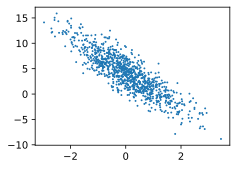

In [120]:
set_figsize()
plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);

In [121]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    # 生成样本编号：
    # [0, 1, 2, 3, ..., 999]
    indices = list(range(num_examples))
    # shuffle() 方法将序列的所有元素随机重新排序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

return：一次性返回结果，然后函数结束

yield：每次返回一个结果，但函数暂停，下一次还能从暂停处继续执行

In [122]:
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[ 0.3319, -0.3384],
        [-1.1209,  0.8150],
        [-0.3587,  1.1080],
        [-0.9617,  0.5397],
        [ 0.0895, -0.7059],
        [ 1.0723, -0.3833],
        [-0.1410, -0.0223],
        [-0.5032, -1.0400],
        [-0.8685, -0.9585],
        [ 0.3556, -0.9986]]) 
 tensor([[ 6.0163],
        [-0.8191],
        [-0.2772],
        [ 0.4466],
        [ 6.7762],
        [ 7.6442],
        [ 3.9966],
        [ 6.7434],
        [ 5.7053],
        [ 8.3088]])


In [123]:
# normal函数的语法是 torch.normal(均值, 标准差, size=(形状), requires_grad=True)，
# 产生一个服从正态分布的张量，均值为0，标准差为0.01，形状为(2,1)，并且需要计算梯度。
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
# zeros产生一个全为0的张量，形状为(1,)，并且需要计算梯度。
b = torch.zeros(1, requires_grad=True)
#requires_grad=True 意思是：PyTorch 要跟踪它们参与的计算。

In [124]:
def linreg(X, w, b):  #@save
    """线性回归模型"""
    return torch.matmul(X, w) + b
def squared_loss(y_hat, y):  #@save
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

In [125]:
def sgd(params, lr, batch_size):  #@save
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

In [129]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)  # X和y的小批量损失
        # 因为l形状是(batch_size,1)，而不是一个标量。l中的所有元素被加到一起，
        # 并以此计算关于[w,b]的梯度
        # 然后把结果存到：
        # w.grad
        # b.grad
        # 即变成param.grad
        # print(f'l.grad_fn at:{epoch + 1} {l.grad_fn}')
        # print(f'w.grad at:{epoch + 1} {w.grad}')
        # print(f'b.grad at:{epoch + 1} {b.grad}')
        l.sum().backward()
        # print(f'w.grad after backward at {epoch + 1}: {w.grad}')
        # print(f'b.grad after backward at {epoch + 1}: {b.grad}')
        sgd([w, b], lr, batch_size)  # 使用参数的梯度更新参数
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.000048
epoch 2, loss 0.000048
epoch 3, loss 0.000048


In [127]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([ 0.0003, -0.0006], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0008], grad_fn=<RsubBackward1>)
